# Road Condition Classification using RexNet
This notebook implements a ResNet-based image classification model to classify road conditions into 15 categories using the Viscoda RoadSaW dataset. Evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix are included.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import timm

## 1. Device Configuration
Check for GPU availability and set up the device configuration.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## 2. Data Directories
Set up paths to the dataset directories.

In [3]:
data_dir = "C:/Users/shres/Documents/dataset/RoadSaW-150_l"
train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'validation')
test_dir = os.path.join(data_dir, 'test')

## 3. Data Transformations
Define transformations to preprocess the images for input into the ResNet model.

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 4. Load Datasets and DataLoaders
Load the train, validation, and test datasets.

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
print(f'Classes: {class_names}')

Classes: ['asphalt_damp', 'asphalt_dry', 'asphalt_verywet', 'asphalt_wet', 'cobble_damp', 'cobble_dry', 'cobble_verywet', 'cobble_wet', 'concrete_damp', 'concrete_dry', 'concrete_verywet', 'concrete_wet', 'fresh_snow', 'fully_packed', 'partially_covered']


## 5. Define the RexNet Model
Modify the ResNet model for classification into 15 categories.

In [6]:

# Define the ReXNet Model
model = timm.create_model('rexnet_100', pretrained=True, num_classes=len(class_names))  # Load ReXNet (1.0x variant)

# Update the fully connected layer to match the number of classes
num_features = model.get_classifier().in_features  # Get the input features of the classifier
model.fc = nn.Linear(num_features, len(class_names))  # Replace the classification layer

# Move the model to the appropriate device
model = model.to(device)

## 6. Loss Function and Optimizer
Set up the loss function and optimizer.

In [7]:
criterion = nn.CrossEntropyLoss()
#optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)

## 7. Train the Model
Train the ResNet model and display loss and accuracy for each epoch.

In [8]:
from sklearn.metrics import precision_recall_fscore_support

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Collect all predictions and labels for calculating precision, recall, and F1-score
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total

    # Calculate precision, recall, and F1-score
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}, '
          f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}')

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds = []
    val_labels = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # Collect all predictions and labels for calculating precision, recall, and F1-score
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc = val_correct / val_total

    # Calculate precision, recall, and F1-score for validation
    val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(val_labels, val_preds, average='weighted')

    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}, '
          f'Validation Precision: {val_precision:.4f}, Validation Recall: {val_recall:.4f}, '
          f'Validation F1-Score: {val_f1:.4f}')


Epoch 1/10, Loss: 0.8083, Accuracy: 0.7059, Precision: 0.7055, Recall: 0.7059, F1-Score: 0.7056


c:\Users\shres\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Validation Loss: 2.0624, Validation Accuracy: 0.4191, Validation Precision: 0.4463, Validation Recall: 0.4191, Validation F1-Score: 0.3776
Epoch 2/10, Loss: 0.7985, Accuracy: 0.6923, Precision: 0.6918, Recall: 0.6923, F1-Score: 0.6917
Validation Loss: 0.7823, Validation Accuracy: 0.6945, Validation Precision: 0.6955, Validation Recall: 0.6945, Validation F1-Score: 0.6833
Epoch 3/10, Loss: 0.4861, Accuracy: 0.7996, Precision: 0.7997, Recall: 0.7996, F1-Score: 0.7993
Validation Loss: 1.0392, Validation Accuracy: 0.6778, Validation Precision: 0.6791, Validation Recall: 0.6778, Validation F1-Score: 0.6499
Epoch 4/10, Loss: 0.4660, Accuracy: 0.8073, Precision: 0.8076, Recall: 0.8073, F1-Score: 0.8071
Validation Loss: 0.7102, Validation Accuracy: 0.7322, Validation Precision: 0.7291, Validation Recall: 0.7322, Validation F1-Score: 0.7241
Epoch 5/10, Loss: 0.3940, Accuracy: 0.8345, Precision: 0.8347, Recall: 0.8345, F1-Score: 0.8344
Validation Loss: 0.6889, Validation Accuracy: 0.7677, Valida

c:\Users\shres\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Validation Loss: 5.7530, Validation Accuracy: 0.1085, Validation Precision: 0.1067, Validation Recall: 0.1085, Validation F1-Score: 0.0659
Epoch 8/10, Loss: 1.0506, Accuracy: 0.6185, Precision: 0.6178, Recall: 0.6185, F1-Score: 0.6177
Validation Loss: 1.1615, Validation Accuracy: 0.6075, Validation Precision: 0.6070, Validation Recall: 0.6075, Validation F1-Score: 0.5903
Epoch 9/10, Loss: 0.7028, Accuracy: 0.7224, Precision: 0.7222, Recall: 0.7224, F1-Score: 0.7219
Validation Loss: 0.8549, Validation Accuracy: 0.7145, Validation Precision: 0.7248, Validation Recall: 0.7145, Validation F1-Score: 0.7096
Epoch 10/10, Loss: 0.5104, Accuracy: 0.7939, Precision: 0.7943, Recall: 0.7939, F1-Score: 0.7937
Validation Loss: 0.9588, Validation Accuracy: 0.6512, Validation Precision: 0.6617, Validation Recall: 0.6512, Validation F1-Score: 0.6475


## 8. Evaluate the Model
Define a function to evaluate the model using metrics like precision, recall, F1-score, ROC-AUC, and confusion matrix.

In [9]:
def evaluate_model(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_proba.extend(torch.nn.functional.softmax(outputs, dim=1).cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    print(f'ROC-AUC: {roc_auc:.4f}')

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))
"""def evaluate_model(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_proba.extend(torch.nn.functional.softmax(outputs, dim=1).cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    #roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-Score: {f1:.4f}')
    #print(f'ROC-AUC: {roc_auc:.4f}')

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))"""

"def evaluate_model(model, dataloader, class_names):\n    model.eval()\n    y_true = []\n    y_pred = []\n    y_proba = []\n\n    with torch.no_grad():\n        for inputs, labels in dataloader:\n            inputs, labels = inputs.to(device), labels.to(device)\n\n            outputs = model(inputs)\n            _, preds = torch.max(outputs, 1)\n\n            y_true.extend(labels.cpu().numpy())\n            y_pred.extend(preds.cpu().numpy())\n            y_proba.extend(torch.nn.functional.softmax(outputs, dim=1).cpu().numpy())\n\n    accuracy = accuracy_score(y_true, y_pred)\n    precision = precision_score(y_true, y_pred, average='weighted')\n    recall = recall_score(y_true, y_pred, average='weighted')\n    f1 = f1_score(y_true, y_pred, average='weighted')\n    #roc_auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')\n    conf_matrix = confusion_matrix(y_true, y_pred)\n\n    print(f'Accuracy: {accuracy:.4f}')\n    print(f'Precision: {precision:.4f}')\n    prin

## 9. Test the Model
Use the test dataset to evaluate the model's performance.

Accuracy: 0.6004
Precision: 0.6164
Recall: 0.6004
F1-Score: 0.5896
ROC-AUC: 0.9701


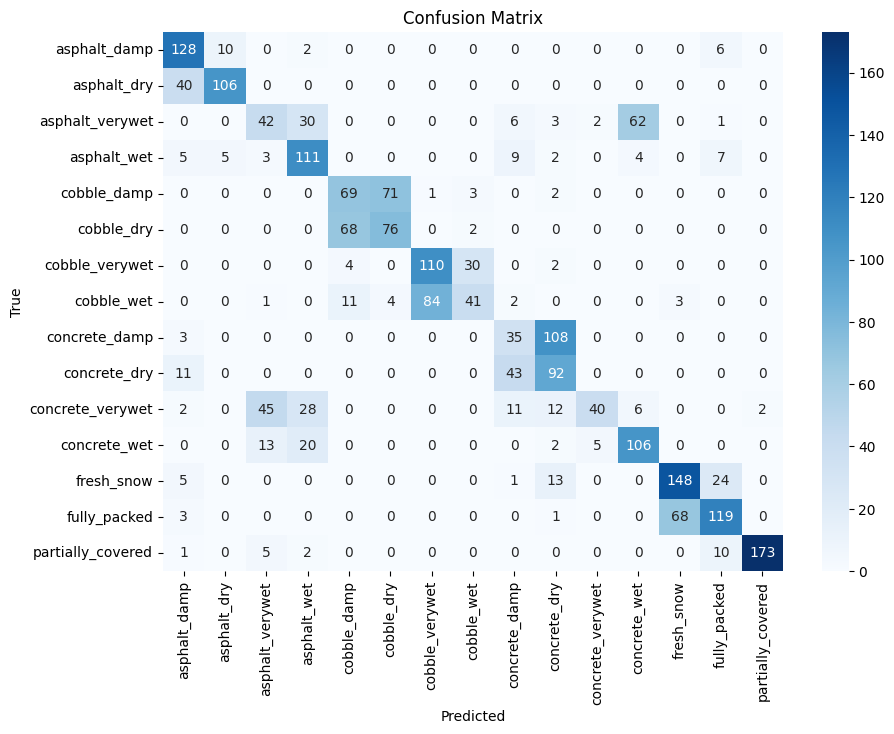


Classification Report:
                   precision    recall  f1-score   support

     asphalt_damp       0.65      0.88      0.74       146
      asphalt_dry       0.88      0.73      0.79       146
  asphalt_verywet       0.39      0.29      0.33       146
      asphalt_wet       0.58      0.76      0.65       146
      cobble_damp       0.45      0.47      0.46       146
       cobble_dry       0.50      0.52      0.51       146
   cobble_verywet       0.56      0.75      0.65       146
       cobble_wet       0.54      0.28      0.37       146
    concrete_damp       0.33      0.24      0.28       146
     concrete_dry       0.39      0.63      0.48       146
 concrete_verywet       0.85      0.27      0.41       146
     concrete_wet       0.60      0.73      0.65       146
       fresh_snow       0.68      0.77      0.72       191
     fully_packed       0.71      0.62      0.66       191
partially_covered       0.99      0.91      0.95       191

         accuracy             

In [10]:
evaluate_model(model, test_loader, class_names)